<a href="https://colab.research.google.com/github/Arshad8979/Arshad_Assignment_DS/blob/main/Wine_Visualization_Arshad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><h1 style="background-color:purple; color:white"><br>Wine Quality - Exploratory Data Analysis<br></h1></center>

## Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

In [5]:
df = pd.read_csv('/content/Wine Quality Dataset.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## Shape of the Dataset

In [6]:
print('Rows, Columns:', df.shape)

Rows, Columns: (4898, 12)


## Data Types & Info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


## Statistical Summary

In [8]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


## Check for Missing Values

In [9]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## Check for Duplicate Rows

In [10]:
print('Duplicates before drop:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after drop:', df.duplicated().sum())

Duplicates before drop: 937
Duplicates after drop: 0


## Distribution of Quality (Target Variable)

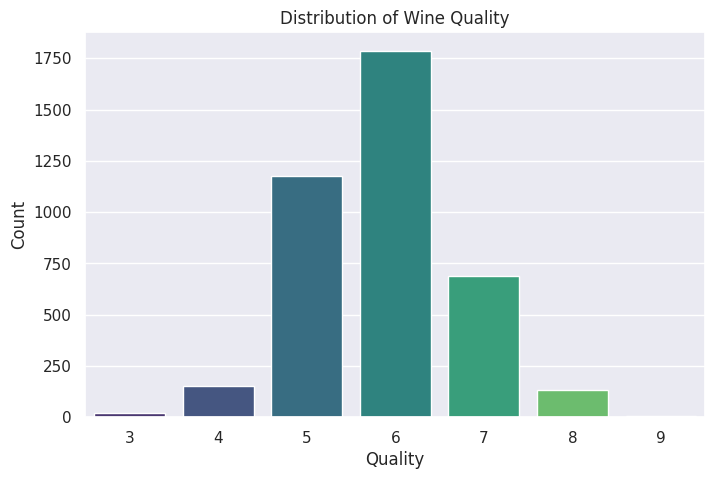

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

## Alcohol Distribution

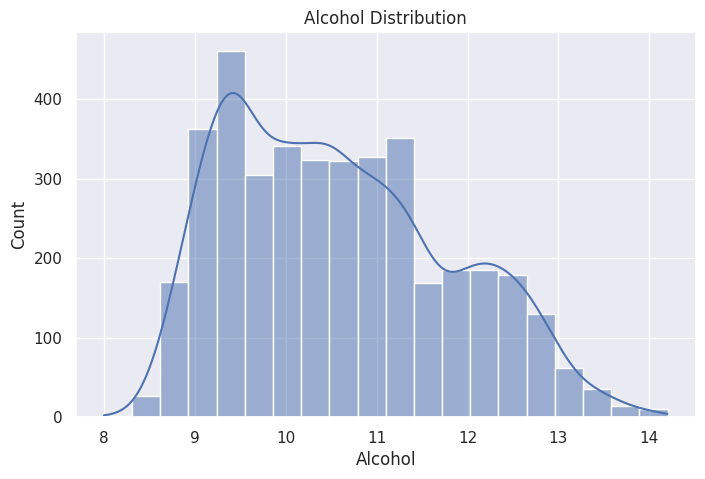

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['alcohol'], bins=20, kde=True)
plt.title('Alcohol Distribution')
plt.xlabel('Alcohol')
plt.ylabel('Count')
plt.show()

## Distribution of All Numeric Features

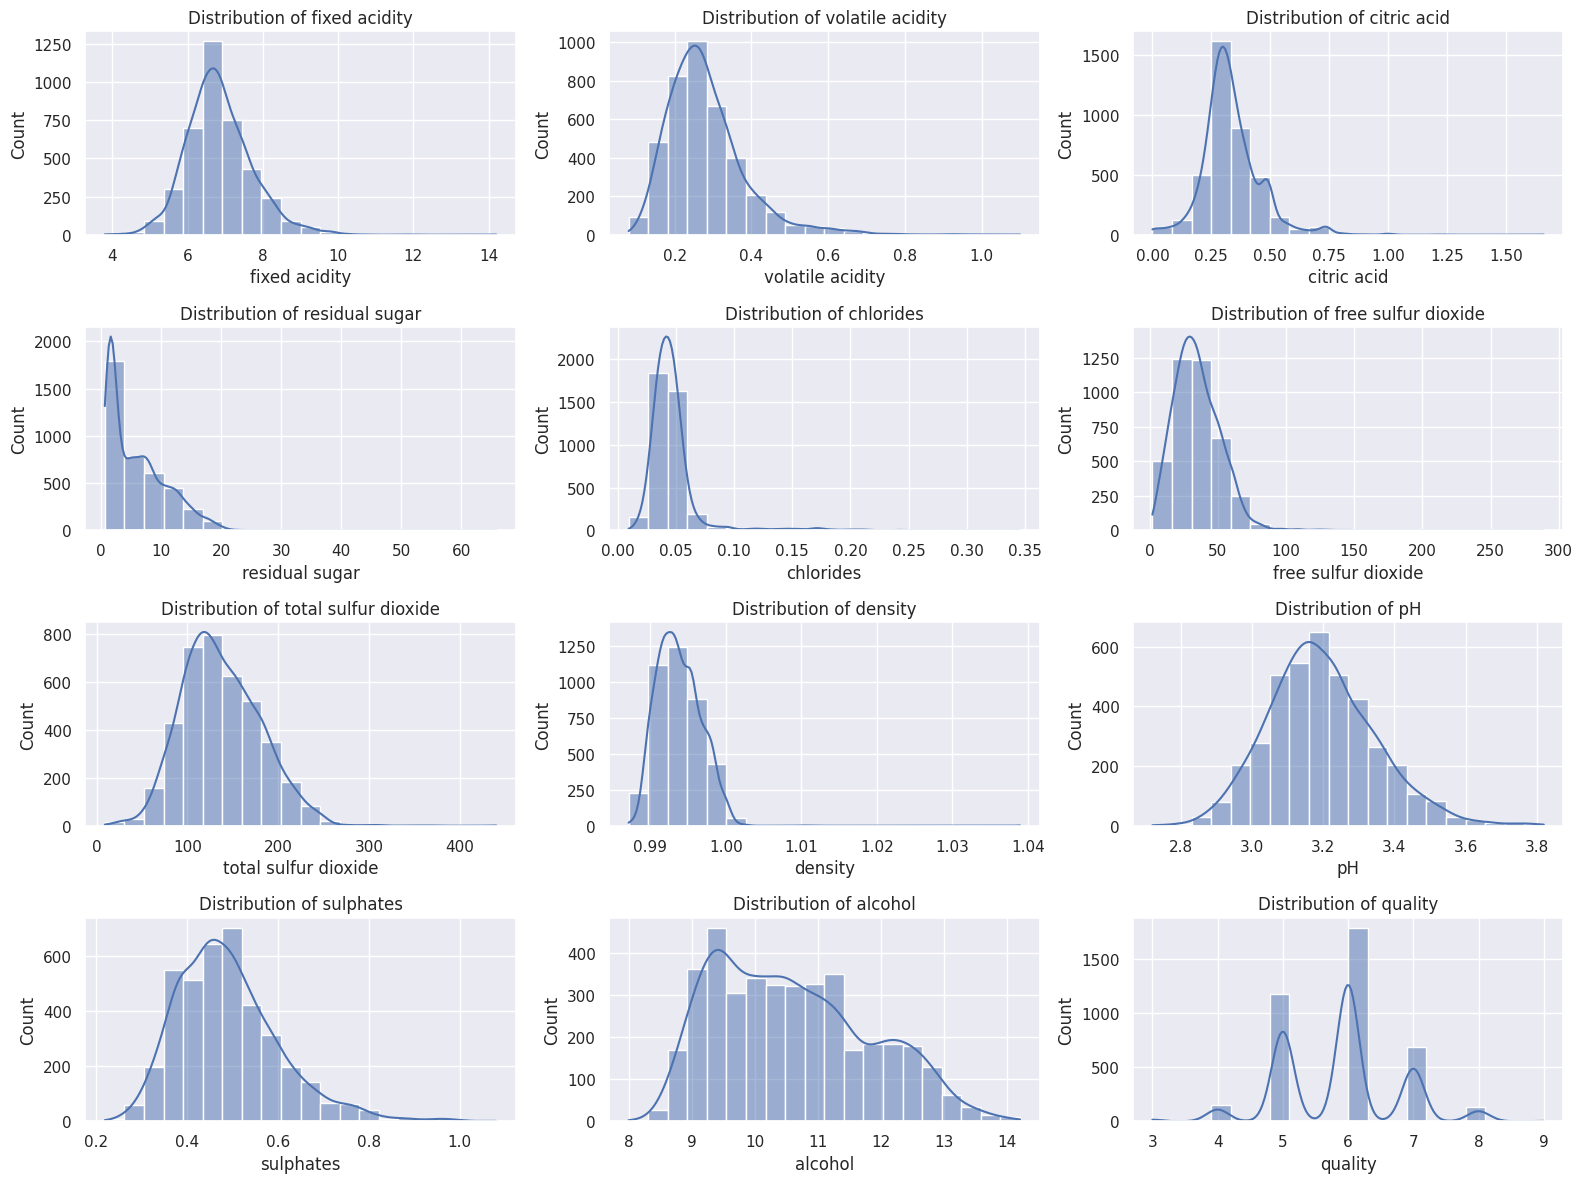

In [13]:
num_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()
plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## Boxplots to Detect Outliers

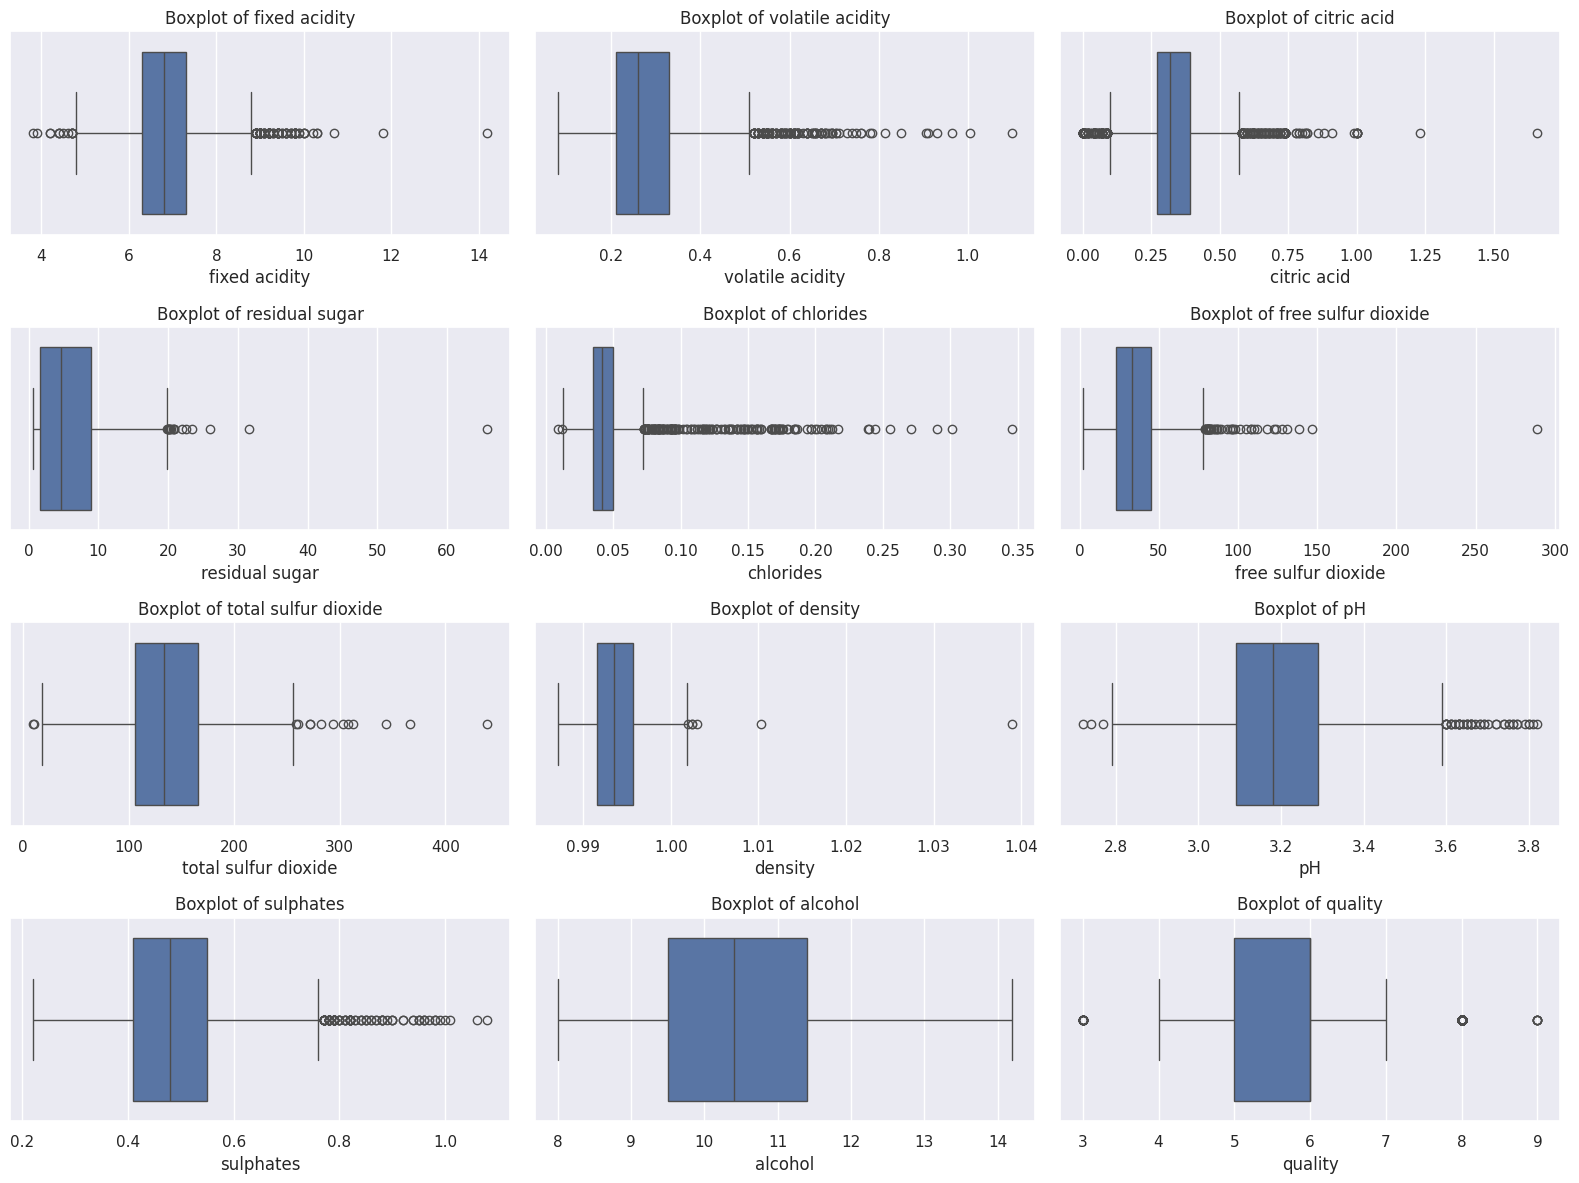

In [14]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

## Correlation Heatmap

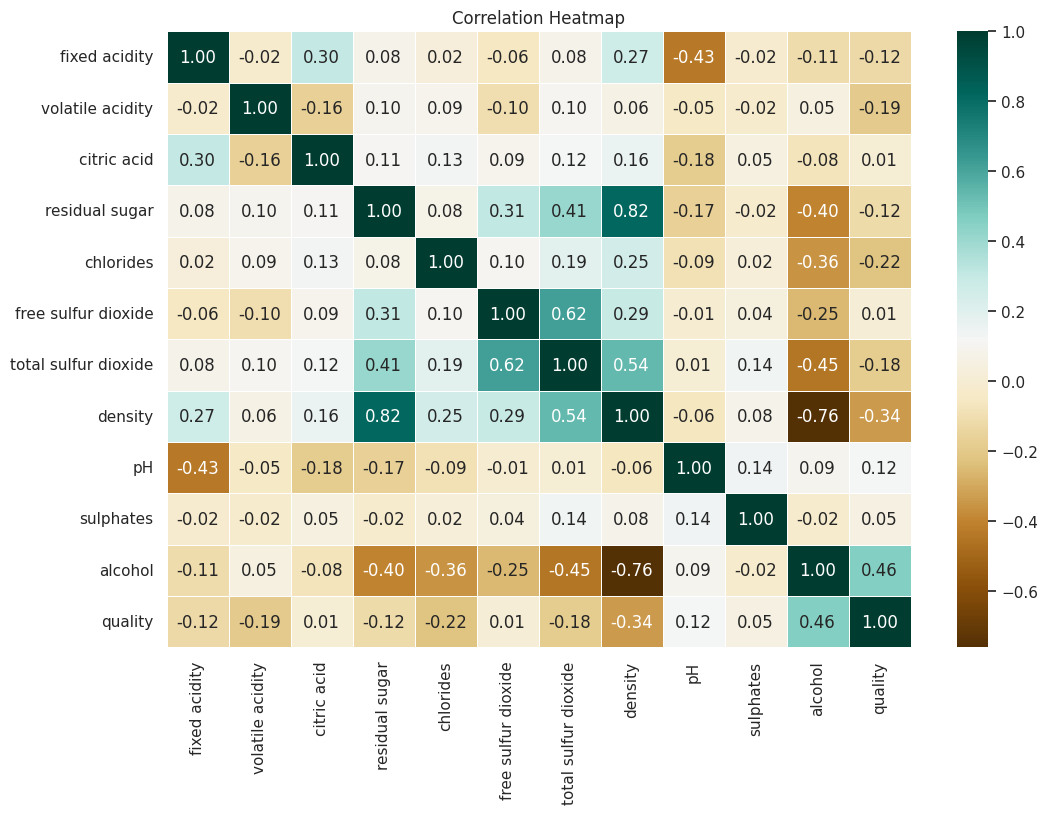

In [15]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='BrBG', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## Alcohol vs Quality

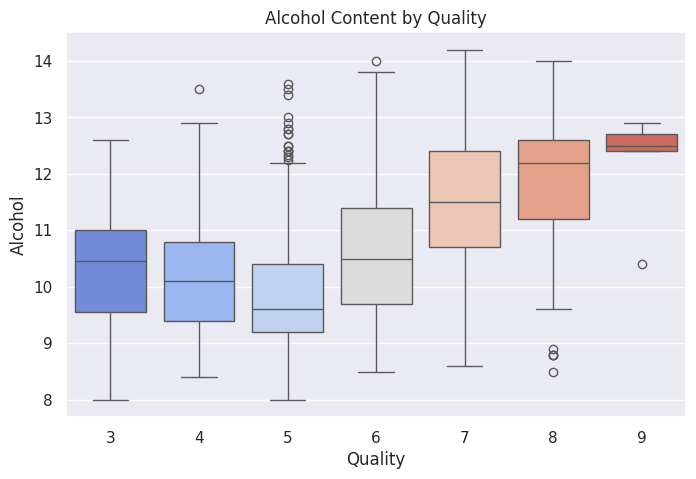

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='alcohol', data=df, palette='coolwarm')
plt.title('Alcohol Content by Quality')
plt.xlabel('Quality')
plt.ylabel('Alcohol')
plt.show()

## Volatile Acidity vs Quality

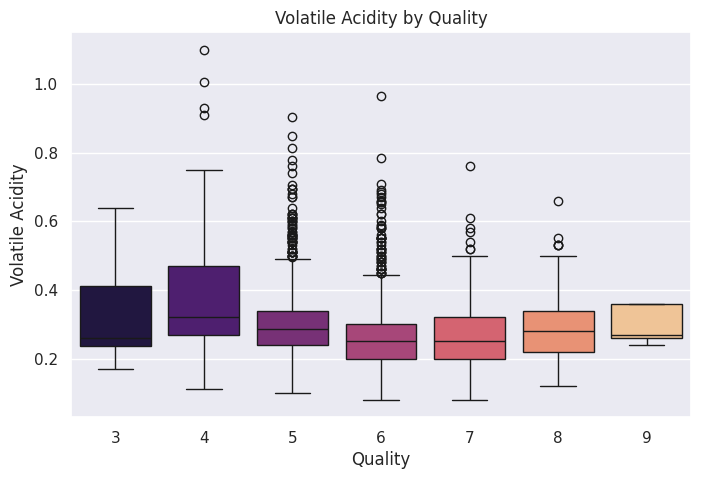

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='volatile acidity', data=df, palette='magma')
plt.title('Volatile Acidity by Quality')
plt.xlabel('Quality')
plt.ylabel('Volatile Acidity')
plt.show()

## Scatter Plot: Alcohol vs Density

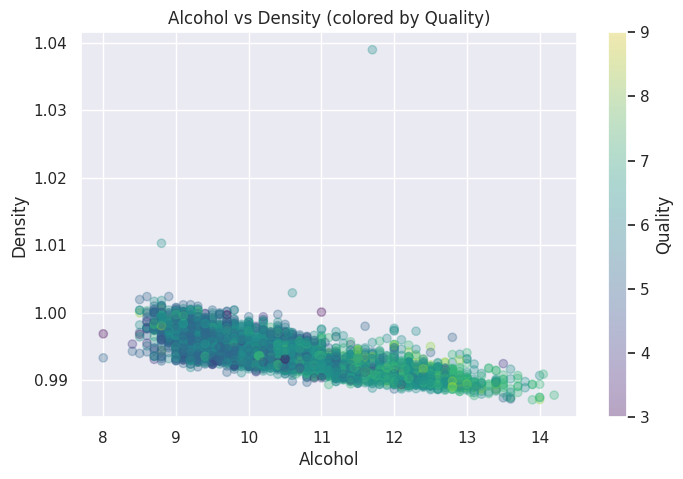

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df['alcohol'], df['density'], alpha=0.3, c=df['quality'], cmap='viridis')
plt.colorbar(label='Quality')
plt.xlabel('Alcohol')
plt.ylabel('Density')
plt.title('Alcohol vs Density (colored by Quality)')
plt.show()

## Pairplot of Key Features

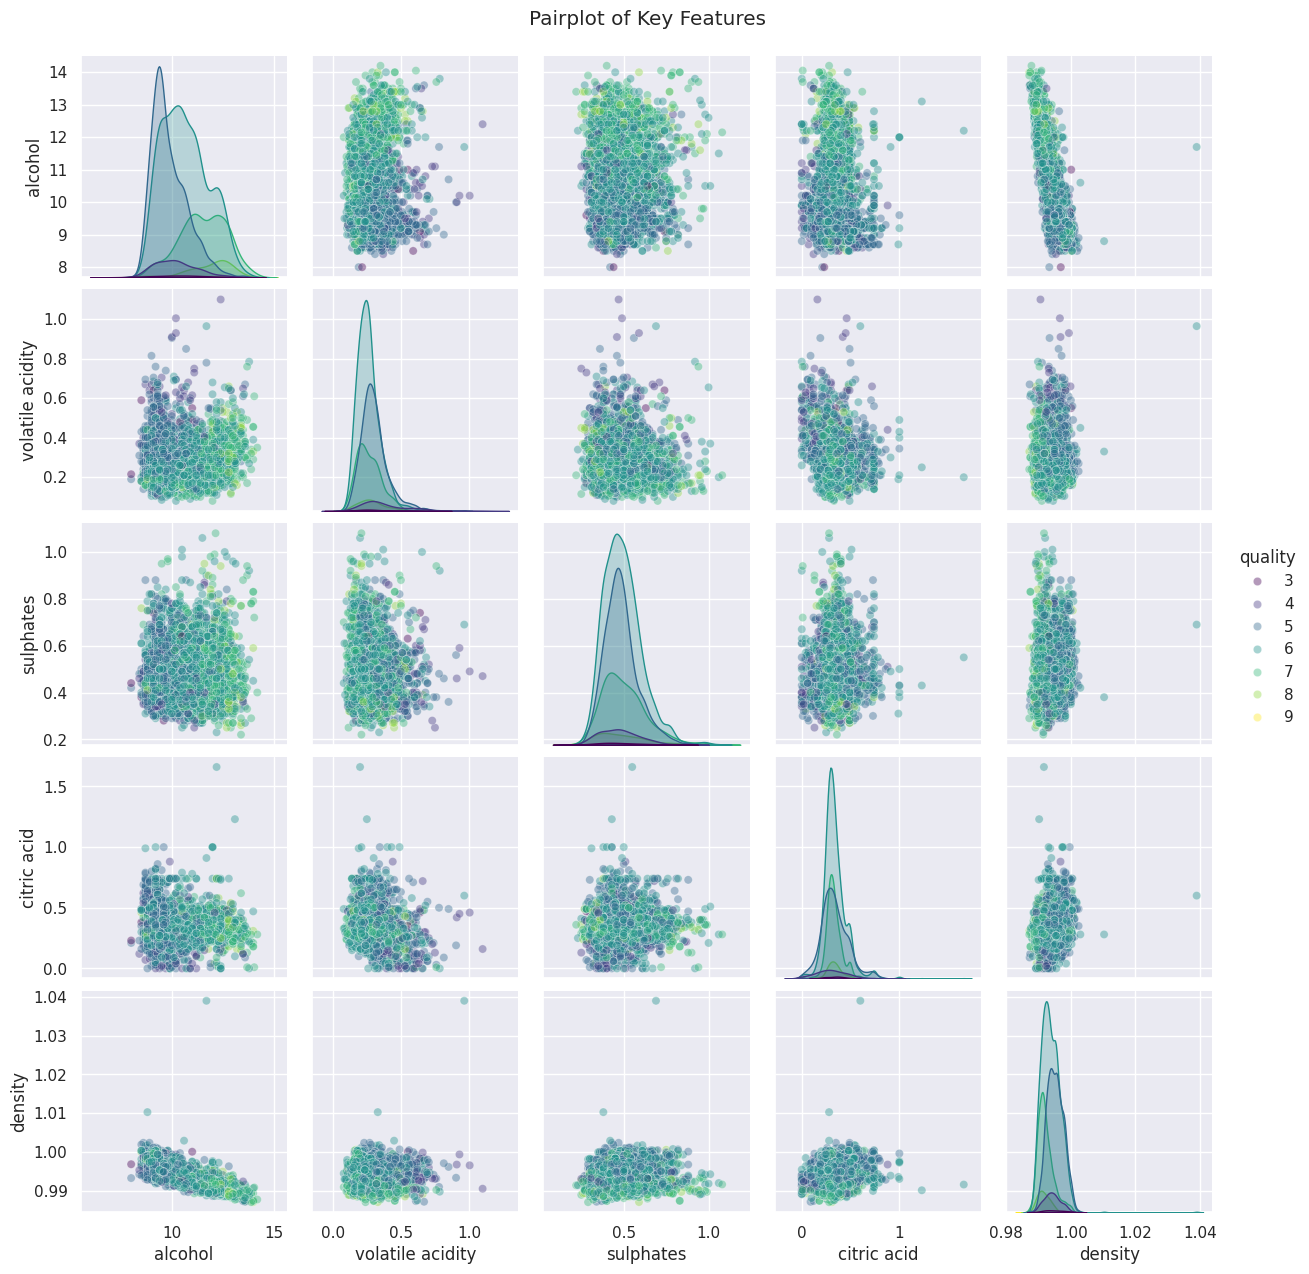

In [19]:
key_cols = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'quality']
sns.pairplot(df[key_cols], hue='quality', palette='viridis', diag_kind='kde', plot_kws={'alpha':0.4})
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.show()

## IQR Outlier Removal

In [20]:
l = df.select_dtypes(include=['float64','int64']).columns.tolist()
Q1 = df[l].quantile(0.25)
Q3 = df[l].quantile(0.75)
IQR = Q3 - Q1
df2 = df[~((df[l] < (Q1 - 1.5 * IQR)) | (df[l] > (Q3 + 1.5 * IQR))).any(axis=1)]
print('Shape before IQR removal:', df.shape)
print('Shape after IQR removal:', df2.shape)

Shape before IQR removal: (3961, 12)
Shape after IQR removal: (3131, 12)


## Average Feature Values by Quality

<Figure size 1200x600 with 0 Axes>

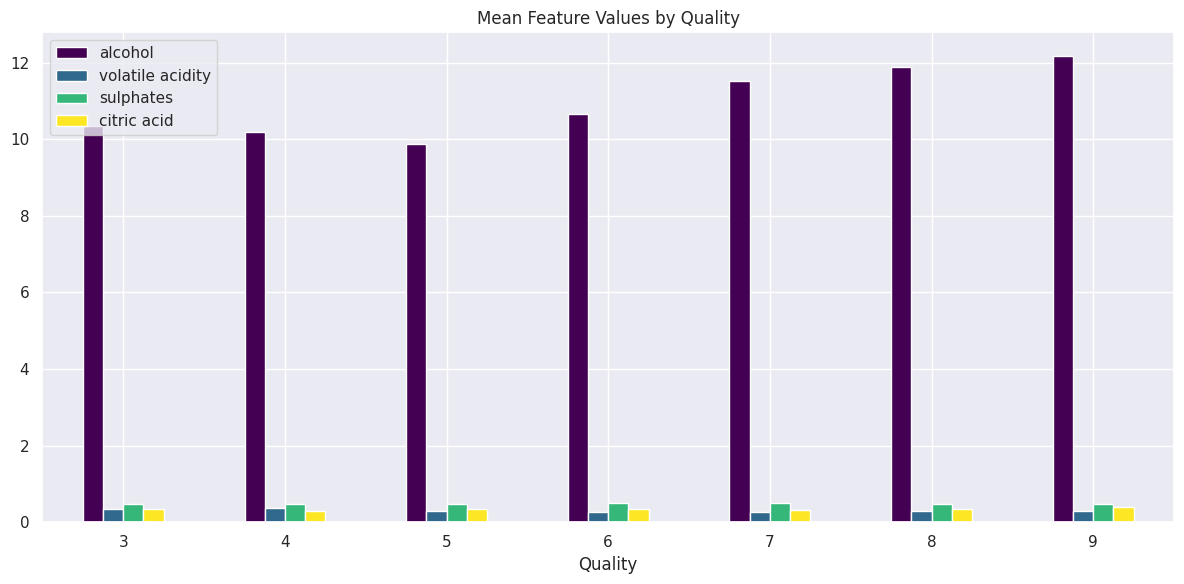

In [21]:
plt.figure(figsize=(12,6))
df.groupby('quality').mean(numeric_only=True)[['alcohol','volatile acidity','sulphates','citric acid']].plot(
    kind='bar', figsize=(12,6), colormap='viridis')
plt.title('Mean Feature Values by Quality')
plt.xlabel('Quality')
plt.xticks(rotation=0)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()